In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Stat I project - FIFA World Cup 2022 player performance

By MacÃ©o Drouot and Axel Bachon

Data: StatsBomb Open Data (men's World Cup 2022, Qatar)

## 1. Loading the data

In [4]:
df = pd.read_csv('statsbomb_world_cup_2022_player_match.csv')
n = len(df)
df

,competition_id,season_id,match_id,match_date,match_name,stage,player_id,player_name,team_id,team_name,...,dribbles,completed_dribbles,pressures,tackles,interceptions,fouls_committed,fouls_won,total_pass_distance,total_carry_distance,expected_goals
0,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,12803,Romario Andrés Ibarra Mina,3565,Ecuador,...,1,1,8,0,0,0,0,170.148306,115.510117,0.136638
1,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,23830,Jhegson Sebastián Méndez Carabalí,3565,Ecuador,...,0,0,9,3,0,3,1,1566.175661,241.277374,0.000000
2,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,24085,Pervis Josué Estupiñán Tenorio,3565,Ecuador,...,1,1,7,3,1,3,0,1465.181417,243.689772,0.000000
3,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,28559,Enner Remberto Valencia Lastra,3565,Ecuador,...,3,2,14,0,0,1,4,264.577535,82.604804,0.872281
4,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,30111,Felix Eduardo Torres Caicedo,3565,Ecuador,...,1,0,4,0,1,0,0,1443.594843,231.100259,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,43,106,3869685,2022-12-18,Argentina - France,Final,7161,Germán Alejandro Pezzella,779,Argentina,...,0,0,0,0,0,0,0,18.220043,0.500000,0.000000
1991,43,106,3869685,2022-12-18,Argentina - France,Final,11456,Lautaro Javier Martínez,779,Argentina,...,0,0,2,0,0,0,0,62.932389,27.414423,0.583520
1992,43,106,3869685,2022-12-18,Argentina - France,Final,16308,Leandro Daniel Paredes,779,Argentina,...,0,0,5,1,0,1,0,281.049523,66.599847,0.000000
1993,43,106,3869685,2022-12-18,Argentina - France,Final,19597,Marcos Javier Acuña,779,Argentina,...,2,0,10,1,0,2,0,559.046995,139.699373,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   competition_id          1995 non-null   int64  
 1   season_id               1995 non-null   int64  
 2   match_id                1995 non-null   int64  
 3   match_date              1995 non-null   object 
 4   match_name              1995 non-null   object 
 5   stage                   1995 non-null   object 
 6   player_id               1995 non-null   int64  
 7   player_name             1995 non-null   object 
 8   team_id                 1995 non-null   int64  
 9   team_name               1995 non-null   object 
 10  opponent_id             1995 non-null   int64  
 11  opponent_name           1995 non-null   object 
 12  is_home                 1995 non-null   int64  
 13  position_id             1995 non-null   int64  
 14  position                1995 non-null   

In [6]:
df.nunique()

competition_id               1
season_id                    1
match_id                    64
match_date                  23
match_name                  64
stage                        6
player_id                  680
player_name                681
team_id                     32
team_name                   32
opponent_id                 32
opponent_name               32
is_home                      2
position_id                 23
position                    23
is_starter                   2
minutes_played            1195
match_duration_minutes      64
extra_time                   2
passes                     126
completed_passes           116
passes_unknown_outcome       5
carries                    107
shots                        9
shots_on_target              6
goals                        4
own_goals                    2
assists                      3
dribbles                    15
completed_dribbles          11
pressures                   37
tackles                     10
intercep

The file has 1,995 rows and 38 columns, with no missing values. One row is one player in one match (64 matches, 32 teams, 680 players). Substitutes who did not come on are not in the file, so every row is a player who actually played (minimum 1.3 minutes).

## 2. Data description

### Population under study

- Population: the appearances of players at the 2022 World Cup (one player in one match where he played)
- Number of observations: 1,995
- Time series (Y/N): N

### Preparing the variables

**position**: the file has 23 detailed positions (Left Back, Right Wing, Center Defensive Midfield, ...). That's too many for a table or a graph, so we group them into 4 roles:

- Goalkeeper
- Defender: all the Back positions (center backs, full backs and wing backs)
- Midfielder: all the Midfield positions
- Forward: wingers and forwards

In [7]:
groups = {}
for p in df.position.unique():
    if p == 'Goalkeeper':
        groups[p] = 'Goalkeeper'
    elif 'Back' in p:
        groups[p] = 'Defender'
    elif 'Wing' in p or 'Forward' in p:
        groups[p] = 'Forward'
    else:
        groups[p] = 'Midfielder'

df['role'] = [groups[p] for p in df.position]
groups

{'Left Midfield': 'Midfielder',
 'Right Defensive Midfield': 'Midfielder',
 'Left Back': 'Defender',
 'Right Center Forward': 'Forward',
 'Right Center Back': 'Defender',
 'Right Midfield': 'Midfielder',
 'Left Center Forward': 'Forward',
 'Goalkeeper': 'Goalkeeper',
 'Left Defensive Midfield': 'Midfielder',
 'Right Back': 'Defender',
 'Left Center Back': 'Defender',
 'Center Forward': 'Forward',
 'Right Center Midfield': 'Midfielder',
 'Center Defensive Midfield': 'Midfielder',
 'Center Back': 'Defender',
 'Right Wing Back': 'Defender',
 'Left Center Midfield': 'Midfielder',
 'Left Wing Back': 'Defender',
 'Left Wing': 'Forward',
 'Center Attacking Midfield': 'Midfielder',
 'Right Wing': 'Forward',
 'Right Attacking Midfield': 'Midfielder',
 'Left Attacking Midfield': 'Midfielder'}

**total_carry_distance**: the distance a player moved with the ball (sum of all his carries). StatsBomb gives it in pitch units, where the pitch is 120 x 80 (this corresponds to yards). We convert it to meters (1 yard = 0.9144 m).

In [8]:
df['carry_m'] = df['total_carry_distance'] * 0.9144
df[['shots', 'carry_m', 'minutes_played']].describe()

,shots,carry_m,minutes_played
count,1995.000000,1995.000000,1995.000000
mean,0.728321,139.103950,73.417738
std,1.158188,119.610739,33.825427
min,0.000000,0.000000,1.286833
25%,0.000000,49.291167,45.945991
50%,0.000000,108.318291,83.737383
75%,1.000000,197.633517,100.147700
max,9.000000,1024.788258,141.410167


### Variables

We chose 3 variables for the project:

| Name | Cat./Disc./Cont. | Obs./Exp. | levels, values or range |
|---|---|---|---|
| role (from position) | Categorical | Observed | Goalkeeper, Defender, Midfielder, Forward |
| shots | Discrete | Observed | 0 to 9 |
| carry_m (total_carry_distance) | Continuous | Observed | 0 to 1,024.8 meters |

Some other variables of the file: minutes_played (continuous, 1.3 to 141.4 min), team_name (categorical, 32 teams), stage (categorical, 6 stages from Group Stage to Final).

### Source and quality

- source: StatsBomb Open Data (https://github.com/statsbomb/open-data), competition 43, season 106. The CSV was built from the event and lineup files of the 64 matches.
- data collection method: census (all the players who played in all the matches of the tournament)
- quality/reliability: StatsBomb is a professional data provider and the definitions are documented. The file was checked (the goals give back the real score of all 64 matches, no duplicates, no missing values). Small limits: the position is only the starting position (changes during the match are not recorded), and the carry distance is a straight line between the start and the end of each carry, not the real distance run.

### Raw/processed

Processed: the CSV is built from the raw StatsBomb event files (counts and sums per player and match). We added two columns: `role` (grouped positions) and `carry_m` (carry distance in meters). No values were removed.

## 3. Frequency tables

### role (categorical)

In [9]:
values_r, counts_r = np.unique(df.role, return_counts=True)
table_r = pd.DataFrame({'freq.': counts_r}, index=values_r)
table_r['rel. freq.'] = counts_r / n
table_r

,freq.,rel. freq.
Defender,669,0.335338
Forward,555,0.278195
Goalkeeper,131,0.065664
Midfielder,640,0.320802


Defenders (34%) and midfielders (32%) are the most common, then forwards (28%). Goalkeepers are only 7% because there is only one per team. No cumulated frequency because there is no order between roles.

### shots (discrete)

In [10]:
values_s, counts_s = np.unique(df.shots, return_counts=True)
table_s = pd.DataFrame({'freq.': counts_s}, index=values_s)
table_s['rel. freq.'] = counts_s / n
table_s['cumul. rel. freq.'] = np.cumsum(table_s['rel. freq.'])
table_s

,freq.,rel. freq.,cumul. rel. freq.
0,1156,0.579449,0.579449
1,505,0.253133,0.832581
2,195,0.097744,0.930326
3,66,0.033083,0.963409
4,31,0.015539,0.978947
5,24,0.012030,0.990977
6,12,0.006015,0.996992
7,5,0.002506,0.999499
9,1,0.000501,1.000000


58% of the players don't shoot at all in a match and 83% shoot at most once. 5 shots or more is very rare (less than 2%). Nobody had 8 shots, and the maximum is 9.

### carry_m (continuous)

We use classes of 50 m between 0 and 400 m. Above 400 m there are few players, so we use bigger classes (400-500, 500-600 and 600-1100) to have at least 5 players in each class.

In [11]:
bins_c = [0, 50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 1100]
counts_c, bins_c = np.histogram(df.carry_m, bins=bins_c)
intervals = list(pd.IntervalIndex.from_breaks(bins_c, closed='left'))
intervals[-1] = pd.Interval(bins_c[-2], bins_c[-1], closed='both')  # last class is closed
table_c = pd.DataFrame({'freq.': counts_c}, index=pd.Index(intervals))
table_c['rel. freq.'] = counts_c / n
table_c['cumul. rel. freq.'] = np.cumsum(table_c['rel. freq.'])
table_c

,freq.,rel. freq.,cumul. rel. freq.
"[0, 50)",505,0.253133,0.253133
"[50, 100)",435,0.218045,0.471178
"[100, 150)",319,0.159900,0.631078
"[150, 200)",250,0.125313,0.756391
"[200, 250)",161,0.080702,0.837093
"[250, 300)",115,0.057644,0.894737
"[300, 350)",92,0.046115,0.940852
"[350, 400)",51,0.025564,0.966416
"[400, 500)",41,0.020551,0.986967
"[500, 600)",18,0.009023,0.995990


Half of the players carry the ball less than about 110 m in a match, and 90% less than 300 m. Only a few players go above 500 m.

## 4. Graphs

### role

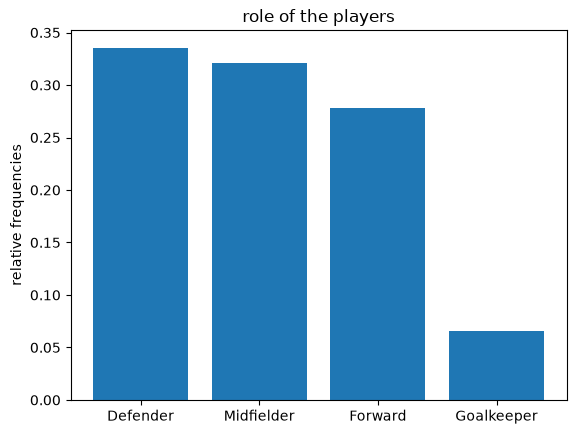

In [12]:
counts = df.role.value_counts()
plt.bar(counts.index, counts.values / n)
plt.ylabel('relative frequencies')
plt.title('role of the players')
plt.show()

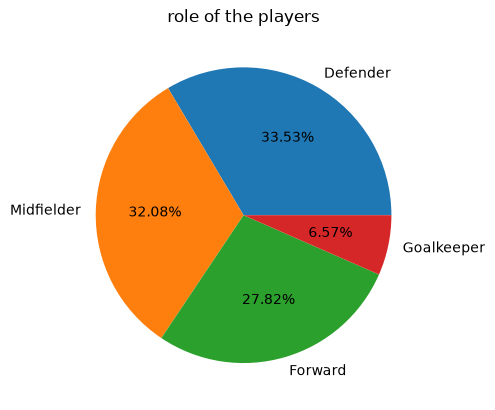

In [13]:
plt.pie(counts.values, labels=counts.index, autopct='%.2f%%')
plt.title('role of the players')
plt.show()

Same result in both graphs: Defender > Midfielder > Forward > Goalkeeper.

### shots

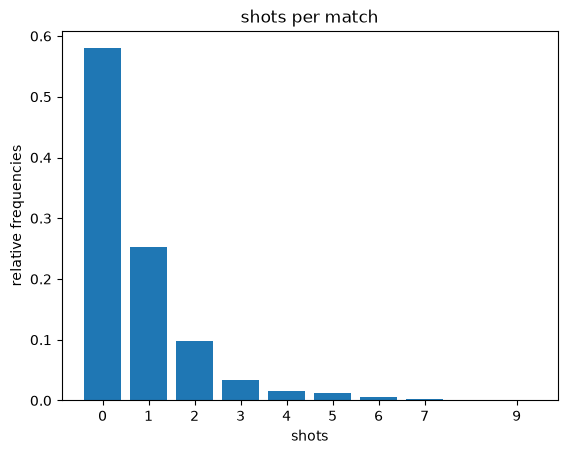

In [14]:
plt.bar(values_s, counts_s / n)
plt.xticks(values_s, values_s)
plt.xlabel('shots')
plt.ylabel('relative frequencies')
plt.title('shots per match')
plt.show()

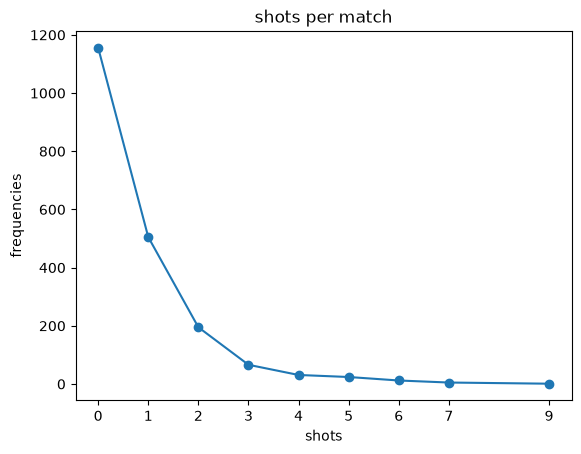

In [15]:
plt.plot(values_s, counts_s, marker='o')
plt.xticks(values_s, values_s)
plt.xlabel('shots')
plt.ylabel('frequencies')
plt.title('shots per match')
plt.show()

The distribution is very skewed to the right: most players have 0 shots in a match and the frequencies go down fast.

### carry_m

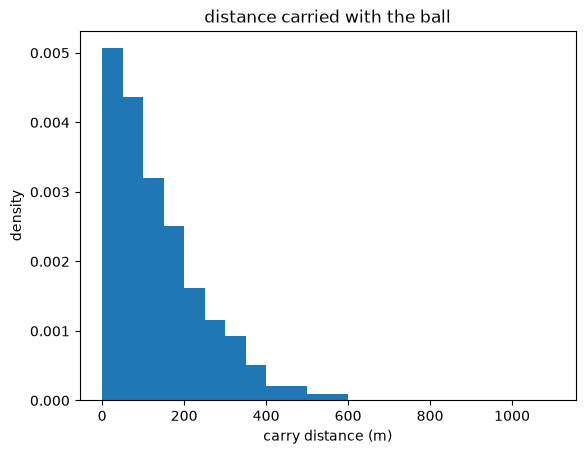

In [16]:
plt.hist(df.carry_m, bins=bins_c, density=True)
plt.xlabel('carry distance (m)')
plt.ylabel('density')
plt.title('distance carried with the ball')
plt.show()

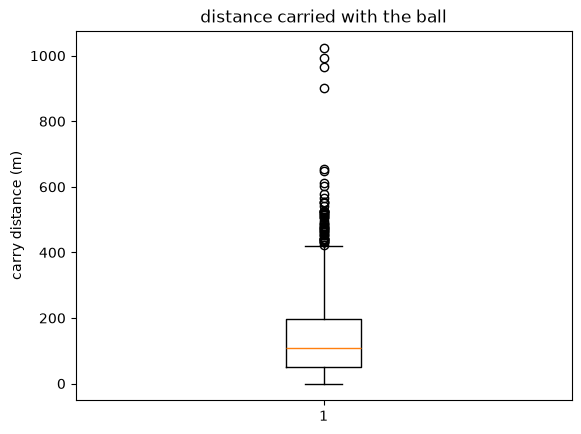

In [17]:
plt.boxplot(df.carry_m)
plt.ylabel('carry distance (m)')
plt.title('distance carried with the ball')
plt.show()

The distribution is also skewed to the right: most players are between 0 and 200 m and there is a long tail to the right. The boxplot shows it too, with a median around 110 m and many points above the upper whisker.

## 5. Outliers

We use the 1.5 x IQR rule: a value is an outlier if it is below Q1 - 1.5 IQR or above Q3 + 1.5 IQR.

In [18]:
for name in ['shots', 'carry_m']:
    q1, q3 = np.quantile(df[name], [.25, .75], method='inverted_cdf')
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    nb_out = ((df[name] < low) | (df[name] > high)).sum()
    print(name, ': limits', round(low, 1), round(high, 1), '-> outliers:', nb_out)

shots : limits -1.5 2.5 -> outliers: 139
carry_m : limits -173.4 420.4 -> outliers: 54


For shots, Q1 = 0 and Q3 = 1, so every player with 3 shots or more is an outlier (139 players, 7%). Let's see who they are:

In [19]:
df[df.shots >= 3].role.value_counts() / len(df[df.shots >= 3])

role
Forward       0.669065
Midfielder    0.266187
Defender      0.064748
Name: count, dtype: float64

Most of them are forwards (67%) and midfielders (27%), so it is normal that they shoot more. These are not errors, just attacking players having a good match.

For carry_m, 54 players are above the upper limit (about 420 m). Let's see who they are:

In [20]:
out_c = df[df.carry_m > high]
print(out_c.role.value_counts() / len(out_c))
print('median minutes played:', out_c.minutes_played.median())

role
Defender      0.611111
Midfielder    0.314815
Forward       0.074074
Name: count, dtype: float64
median minutes played: 101.056467


They are mostly defenders (61%) and midfielders (32%) who played the whole match (median about 101 min). Defenders often carry the ball forward from the back, so these values make sense. These are not errors either, so we keep all the outliers.